Что я хочу, чтобы ты сделал?
- Пиши функции детекции для свечных паттернов(бычье и медвежье поглощение есть, код приведу ниже). Ты можешь писать про те паттерны, которые хочешь, бери самые основные. Каждая функция должна возвращать старый датафрейм + новый столбик с названием 'pattern'. В этом столбике все значения равны 0, кроме тех строк, которые образуют свечной паттерн, там пиши 1. Если паттерн состоит из 2 свеч, то 2 строчки должны быть помечены однёрками. Разделяй паттерны на бычьи и медвежьи, то есть нужно писать по 2 фунцкии. 
Если функции будут очень долго думать, то попроси gpt изменить тип данных в столбцах с int64 на int16, или с float64 на float16. Прочитай, что это означает, потом может пригодится. Если и это не поможет, то попроси, чтобы дружбан написал всё это дело в векторном виде с помощью numpy.

- Если вдруг тебе не захочется спать на неделе, то могу предложить написать функцию для создания новых признаков. Функция должна создавать 10-20 новых столбцов с информацией про различные индикаторы: разные скользяшки, rsi, macd, stochastic и прочее. 



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
sber = pd.read_csv('data/SBRF.txt')

In [15]:
sber

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,SBRF,1,20090111,103000,2301,2335,2301,2321,123
1,SBRF,1,20090111,103100,2321,2321,2265,2269,194
2,SBRF,1,20090111,103200,2310,2344,2310,2344,383
3,SBRF,1,20090111,103300,2344,2346,2333,2333,67
4,SBRF,1,20090111,103400,2334,2334,2334,2334,2
...,...,...,...,...,...,...,...,...,...
3298843,SBRF,1,20250630,234400,29851,29851,29845,29845,28
3298844,SBRF,1,20250630,234500,29843,29845,29829,29845,39
3298845,SBRF,1,20250630,234700,29828,29828,29827,29827,3
3298846,SBRF,1,20250630,234800,29832,29841,29805,29815,262


In [16]:
def good_dataframe(data):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame с индексом времени
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    """
  # 1. Удаляем ненужные столбцы (тикер и период не нужны для анализа)
  data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
    
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
    
  # 7. Устанавливаем комбинированную метку времени как индекс
  data = data.set_index('time')
    
  # 8. Создаем резервную копию для безопасного использования
  data_copy = data.copy()
  
  return data, data_copy


In [17]:
sber_df, sber_df_copy = good_dataframe(sber)

In [18]:
sber_df

,open,high,low,close,volume
time,,,,,
2009-01-11 10:30:00,2301,2335,2301,2321,123
2009-01-11 10:31:00,2321,2321,2265,2269,194
2009-01-11 10:32:00,2310,2344,2310,2344,383
2009-01-11 10:33:00,2344,2346,2333,2333,67
2009-01-11 10:34:00,2334,2334,2334,2334,2
...,...,...,...,...,...
2025-06-30 23:44:00,29851,29851,29845,29845,28
2025-06-30 23:45:00,29843,29845,29829,29845,39
2025-06-30 23:47:00,29828,29828,29827,29827,3


In [19]:
def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """
    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    
    return return_data


In [20]:
# Можешь выбрать любой датафрейм, прочитай в функции, что да как там работает
sber_1h = new_timeframe(sber_df, '1h')
sber_1h = sber_1h.reset_index() # Это важно, без этого работать не будет

In [21]:
def detection_bullish_engulfing_pattern(data):
    data['body'] = (data['close'] - data['open'])
    data['pattern'] = 0
    
    # Бычье поглощение 
    data_bull = data.copy()
    for i in range(1, len(data_bull)):
        previous_row = data_bull.iloc[i - 1]
        current_row = data_bull.iloc[i]
    
        if (previous_row['body'] < 0 and current_row['body'] > 0) and (previous_row['open'] < current_row['close']) and (previous_row['close'] > current_row['open']):
            data_bull.loc[i-1, 'pattern'] = 1
            data_bull.loc[i, 'pattern'] = 1
            
    return data_bull
            

In [22]:
def detection_bearish_engulfing_pattern(data):
    data['body'] = (data['close'] - data['open'])
    data['pattern'] = 0
    
    # Медвежье поглощение
    data_bear = data.copy()
    for i in range(1, len(data_bear)):
        previous_row = data_bear.iloc[i - 1]
        current_row = data_bear.iloc[i]
    
        if (previous_row['body'] > 0 and current_row['body'] < 0) and (previous_row['open'] > current_row['close']) and (previous_row['close'] < current_row['open']):
            data_bear.loc[i-1, 'pattern'] = -1
            data_bear.loc[i, 'pattern'] = -1
            
    return data_bear

In [23]:
sber_1h_bull = detection_bullish_engulfing_pattern(sber_1h)
sber_1h_bear = detection_bearish_engulfing_pattern(sber_1h)

In [24]:
sber_1h_bull


,time,open,high,low,close,volume,body,pattern
0,2009-01-11 10:00:00,2301.0,2380.0,2265.0,2361.0,7797,60.0,0
1,2009-01-11 11:00:00,2366.0,2369.0,2324.0,2346.0,5669,-20.0,0
2,2009-01-11 12:00:00,2346.0,2354.0,2328.0,2339.0,2264,-7.0,0
3,2009-01-11 13:00:00,2335.0,2346.0,2330.0,2338.0,876,3.0,0
4,2009-01-11 14:00:00,2339.0,2342.0,2333.0,2334.0,860,-5.0,0
...,...,...,...,...,...,...,...,...
58520,2025-06-30 19:00:00,29871.0,29892.0,29830.0,29859.0,1093,-12.0,0
58521,2025-06-30 20:00:00,29858.0,29879.0,29847.0,29857.0,756,-1.0,0
58522,2025-06-30 21:00:00,29857.0,29876.0,29854.0,29865.0,1059,8.0,0
58523,2025-06-30 22:00:00,29870.0,29874.0,29834.0,29838.0,802,-32.0,0


In [ ]:
sber_1h_bull.info()
# Обрати внимание на размер занимаемой памяти - 3.6 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58525 entries, 0 to 58524
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   time     58525 non-null  datetime64[ns]
 1   open     58525 non-null  float64       
 2   high     58525 non-null  float64       
 3   low      58525 non-null  float64       
 4   close    58525 non-null  float64       
 5   volume   58525 non-null  int64         
 6   body     58525 non-null  float64       
 7   pattern  58525 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 3.6 MB


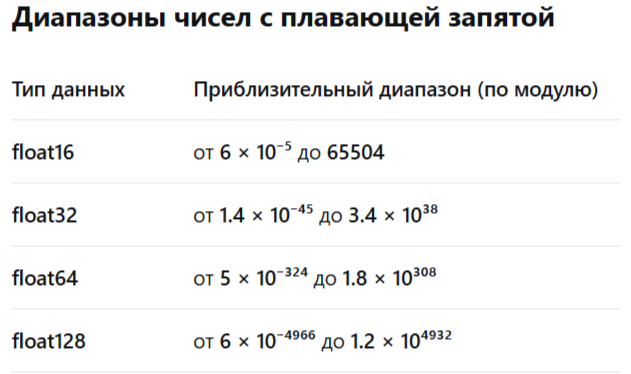

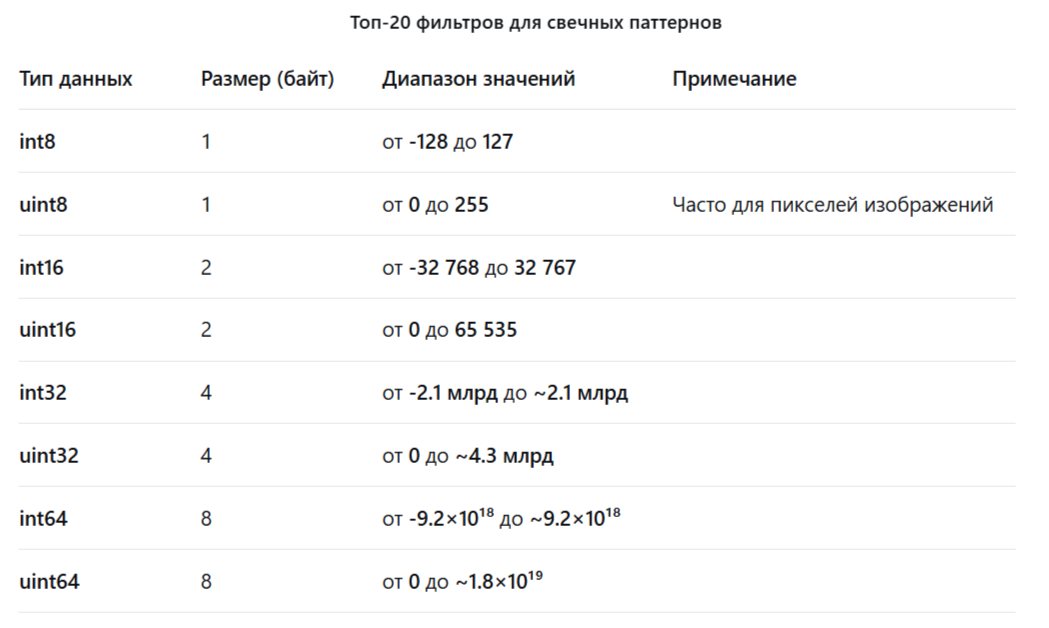

In [27]:
sber_1h_bull.describe()

,time,open,high,low,close,volume,body,pattern
count,58525,58525.000000,58525.000000,58525.000000,58525.000000,58525.000000,58525.000000,58525.000000
mean,2017-05-02 08:21:54.146091264,16641.475147,16693.754942,16588.523281,16641.685399,35585.183956,0.210252,0.073644
min,2009-01-11 10:00:00,1392.000000,1406.000000,1310.000000,1391.000000,9.000000,-7054.000000,0.000000
25%,2013-03-18 11:00:00,9063.000000,9096.000000,9033.000000,9065.000000,6926.000000,-28.000000,0.000000
50%,2017-05-17 12:00:00,14735.000000,14779.000000,14681.000000,14736.000000,21631.000000,1.000000,0.000000
75%,2021-06-16 07:00:00,24222.000000,24293.000000,24160.000000,24222.000000,51943.000000,29.000000,0.000000
max,2025-06-30 23:00:00,39209.000000,39270.000000,39124.000000,39209.000000,501255.000000,3734.000000,1.000000
std,NaN,8782.689585,8799.637438,8764.579714,8782.403083,39153.770837,94.793131,0.261192


In [28]:
# Для всех столбцов, кроме volume нам хватит float16, так как максимальное число меньше 65K
# Изменяем тип данных
sber_1h_bull['open'] = sber_1h_bull['open'].astype('float16')
sber_1h_bull['high'] = sber_1h_bull['high'].astype('float16')
sber_1h_bull['low'] = sber_1h_bull['low'].astype('float16')
sber_1h_bull['close'] = sber_1h_bull['close'].astype('float16')
sber_1h_bull['body'] = sber_1h_bull['body'].astype('float16')
sber_1h_bull['volume'] = sber_1h_bull['volume'].astype('int32')
sber_1h_bull['pattern'] = sber_1h_bull['pattern'].astype('int8')

In [ ]:
sber_1h_bull.info()
# Вуаля, сократили в 3 раза объём таблички. Но лучше всего это делать в самой начале, а не в конце

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58525 entries, 0 to 58524
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   time     58525 non-null  datetime64[ns]
 1   open     58525 non-null  float16       
 2   high     58525 non-null  float16       
 3   low      58525 non-null  float16       
 4   close    58525 non-null  float16       
 5   volume   58525 non-null  int32         
 6   body     58525 non-null  float16       
 7   pattern  58525 non-null  int8          
dtypes: datetime64[ns](1), float16(5), int32(1), int8(1)
memory usage: 1.3 MB
